In [ ]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

Mounted at /content/gdrive


In [ ]:
from pathlib import Path
from dataclasses import dataclass

from typing import Tuple, List, Dict, Any, Optional
import os
import sys
# ATTENTION
# Requires adding folder shortcut to MyDrive
PROJECT_ROOT = Path('/content/gdrive/MyDrive/DoRAFinalProject')
Results = PROJECT_ROOT / 'Results'

In [ ]:
# Claude Helped making config look nice
@dataclass
class Config:
    # ── Model ─────────────────────────────────────────────────────────────
    model_id: str = "meta-llama/Llama-3.2-1B"
    dtype:    str = "bfloat16"

    # ── LoRA / DoRA hyper-params ──────────────────────────────────────────
    rank:          int   = 8
    lora_alpha:    int   = 16    # s = alpha/rank = 2.0
    lora_dropout:  float = 0.05
    target_modules: Tuple[str, ...] = (
        "q_proj", "k_proj", "v_proj",
        "up_proj", "down_proj"
    )

    # ── Training data ─────────────────────────────────────────────────────
    dataset_name: str   = "zwhe99/commonsense_170k"
    n_train:      int   = 20_000
    n_val:        int   = 500
    max_seq_len:  int   = 512
    batch_size:   int   = 16
    grad_accum:   int   = 4
    lr:           float = 2e-4
    n_steps:      int   = 940  # 3 epochs

    warmup_ratio: float = 0.1

    # Two seeds for robustness: LoRA & manual_DoRA are run at both.
    seed:         int   = 67
    alt_seed:     int   = 13

    # ── Evaluation ────────────────────────────────────────────────────────
    n_bench_samples: int = 1000
    eval_batch_size: int = 8
    eval_steps:      int = 100   # was 250 → finer-grained eval-loss curve
    logging_steps:   int = 5     # was 10  → smoother training-loss curve

    # ── I/O ───────────────────────────────────────────────────────────────
    output_dir: str = "/content/gdrive/MyDrive/DoRAFinalProject/Results"

config = Config()
os.makedirs(config.output_dir, exist_ok=True)


In [ ]:
import json
import os
import numpy as np

results_path = os.path.join(Results, "dora_experiment_results.json")
md_npz_path = os.path.join(Results, "dora_md_per_row.npz")

# Only load if 'results' isn't already defined from a fresh run
if 'results' not in locals() or not results:
    if os.path.exists(results_path):
        with open(results_path, "r", encoding="utf-8") as f:
            results = json.load(f)
        print(f"Successfully loaded results from {results_path}")

        # Load the per-row M/D arrays to support the distribution plots
        md_per_row_all = {}
        if os.path.exists(md_npz_path):
            try:
                npz = np.load(md_npz_path)
                for full_key in npz.files:
                    run_key, mod_name, kind = full_key.split("::")
                    md_per_row_all.setdefault(run_key, {}).setdefault(mod_name, {})[kind] = npz[full_key]
                results["__md_per_row__"] = md_per_row_all
                print(f"Successfully loaded M/D row data from {md_npz_path}")
            except Exception as e:
                print(f"Could not load md_npz: {e}")
    else:
        print(f"Results file not found at {results_path}. Please check your Google Drive.")
else:
    print("Results already loaded in memory.")

Successfully loaded results from /content/gdrive/MyDrive/DoRAFinalProject/Results/dora_experiment_results.json
Successfully loaded M/D row data from /content/gdrive/MyDrive/DoRAFinalProject/Results/dora_md_per_row.npz


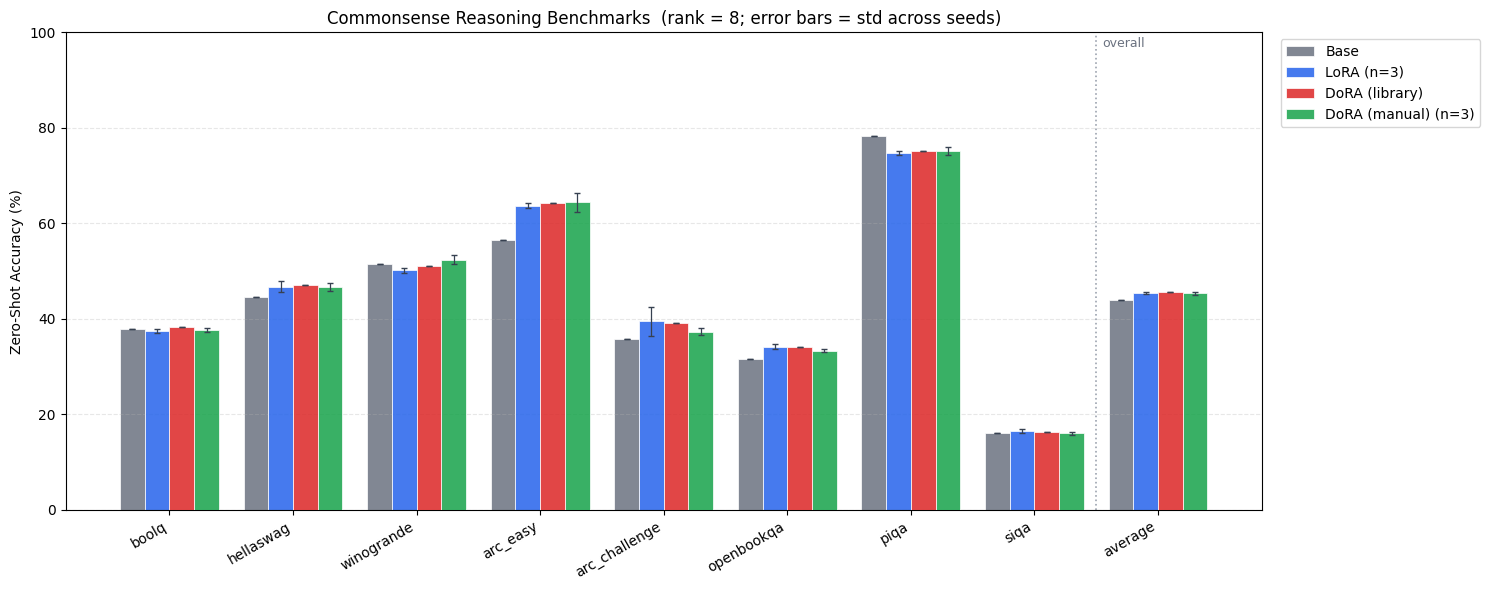

Saved benchmark plot to /content/gdrive/MyDrive/DoRAFinalProject/Results/bench_accuracies.png
1230000000

=== Final Summary Table (accuracy in %; mean±std across seeds where n>1) ===


,,#Params,boolq,hellaswag,winogrande,arc_easy,arc_challenge,openbookqa,piqa,siqa,Avg,seeds
variant,rank,,,,,,,,,,,
Base,—,0%,37.80,44.60,51.60,56.60,35.79,31.60,78.20,16.20,44.05,1
LoRA,8,0.3090%,37.43±0.38,46.77±1.11,50.20±0.53,63.74±0.56,39.46±2.97,34.20±0.53,74.70±0.46,16.53±0.50,45.38±0.18,3
DoRA (library),8,0.3263%,38.30,47.20,51.10,64.21,39.13,34.20,75.20,16.40,45.72,1
DoRA (manual),8,0.3263%,37.77±0.42,46.77±0.84,52.43±0.93,64.39±2.02,37.35±0.77,33.33±0.31,75.13±0.91,16.10±0.30,45.41±0.33,3
LoRA,4,0.1545%,37.63±0.65,46.13±1.16,49.97±1.15,63.27±2.09,37.24±2.02,33.47±1.10,75.23±0.29,16.83±0.64,44.97±0.42,3
DoRA (manual),4,0.1718%,38.53±0.38,46.43±0.23,50.70±0.70,63.86±1.73,35.90±1.08,33.67±0.42,75.07±0.38,16.83±0.68,45.12±0.37,3
LoRA,2,0.0773%,38.40±1.23,45.90±0.66,50.07±0.99,62.22±1.88,34.78±2.34,32.40±0.72,74.83±0.29,16.73±0.21,44.42±0.61,3
DoRA (manual),2,0.0946%,38.63±0.78,46.40±0.36,50.23±0.31,63.80±1.11,35.34±0.77,33.53±0.61,75.00±0.20,16.77±0.57,44.96±0.18,3


Saved final summary table to /content/gdrive/MyDrive/DoRAFinalProject/Results/final_summary_table.csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# ── Helpers to slice the multi-run results dict ───────────────────────────
def _is_run_entry(k, v):
    return (k not in ("base", "__md_per_row__")
            and isinstance(v, dict) and "variant" in v)

def runs_filter(results, variant=None, rank=None, seed=None):
    """Return list of run dicts matching the given filters."""
    out = []
    for k, v in results.items():
        if not _is_run_entry(k, v):
            continue
        if variant is not None and v["variant"] != variant: continue
        if rank    is not None and v["rank"]    != rank:    continue
        if seed    is not None and v["seed"]    != seed:    continue
        out.append(v)
    return out

variants_in_main = ["base", "lora", "dora", "manual_dora"]
bench_names = [
    "boolq", "hellaswag", "winogrande",
    "arc_easy", "arc_challenge", "openbookqa",
    "piqa", "siqa",
]
bench_names_with_avg = bench_names + ["average"]

STYLE = {
    "base":        {"color": "#6B7280", "z": 1, "label": "Base"},
    "lora":        {"color": "#2563EB", "z": 2, "label": "LoRA"},
    "manual_dora": {"color": "#16A34A", "z": 3, "label": "DoRA (manual)"},
    "dora":        {"color": "#DC2626", "z": 4, "label": "DoRA (library)"},
}

main_rank = config.rank

# ── (mean, std, n) per (variant, task) at main rank ───────────────────────
def variant_stats(variant, rank):
    """Return (means_pct, stds_pct, n_seeds) for each task in bench_names_with_avg."""
    if variant == "base":
        b = results.get("base", {}).get("benchmarks", {})
        means = [b.get(bn, np.nan) * 100 for bn in bench_names_with_avg]
        stds  = [0.0] * len(bench_names_with_avg)
        return means, stds, 1

    runs = runs_filter(results, variant=variant, rank=rank)
    if not runs:
        return ([np.nan] * len(bench_names_with_avg),
                [0.0]    * len(bench_names_with_avg),
                0)

    arr = np.array([
        [r["benchmarks"].get(bn, np.nan) * 100 for bn in bench_names_with_avg]
        for r in runs
    ])  # shape [n_seeds, n_tasks]
    means = np.nanmean(arr, axis=0).tolist()
    # ddof=1 sample std when we have ≥2 seeds; else 0.
    stds  = (np.nanstd(arr, axis=0, ddof=1) if arr.shape[0] > 1
             else np.zeros(arr.shape[1])).tolist()
    return means, stds, arr.shape[0]


# ── Bar plot at main rank with seed error bars ────────────────────────────
visible = [v for v in variants_in_main
           if v == "base" or runs_filter(results, variant=v, rank=main_rank)]
n_var   = len(visible)
width   = 0.2
x       = np.arange(len(bench_names_with_avg))
offsets = np.linspace(-(n_var - 1) / 2, (n_var - 1) / 2, n_var) * width

plt.figure(figsize=(15, 6))
ax = plt.gca()

for i, var in enumerate(visible):
    s = STYLE[var]
    means, stds, n_seeds = variant_stats(var, main_rank)
    means_plot = [0.0 if np.isnan(m) else m for m in means]
    label = s["label"] + (f" (n={n_seeds})" if n_seeds > 1 else "")
    ax.bar(
        x + offsets[i], means_plot, width,
        yerr=stds, capsize=2.5,
        color=s["color"], alpha=0.85, edgecolor="white", linewidth=0.6,
        ecolor="#374151", error_kw={"linewidth": 0.9},
        label=label, zorder=s["z"],
    )

# Visual divider between the 8 task bars and the overall-average group.
divider_x = len(bench_names) - 0.5
ax.axvline(divider_x, color="#9CA3AF", linestyle=":", linewidth=1.2, zorder=0)
ax.text(divider_x + 0.05, 99, "overall", color="#6B7280",
        fontsize=9, ha="left", va="top")

ax.set_xticks(x)
ax.set_xticklabels(bench_names_with_avg, rotation=30, ha="right")
ax.set_ylim(0, 100)
ax.set_ylabel("Zero-Shot Accuracy (%)")
ax.set_title(f"Commonsense Reasoning Benchmarks  (rank = {main_rank}; error bars = std across seeds)")
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))
plt.tight_layout()

plot_path = os.path.join(config.output_dir, "bench_accuracies.png")
plt.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved benchmark plot to {plot_path}")


# ── Final summary table ───────────────────────────────────────────────────
# One row per (variant, rank). For (variant, main_rank) with multiple seeds,
# values are formatted as "mean ± std". For single-seed cells (base, library
# DoRA at main rank, rank-4 runs), just the value.
def _fmt(mean, std, n):
    if np.isnan(mean):
        return "—"
    if n <= 1 or std == 0.0:
        return f"{mean:.2f}"
    return f"{mean:.2f}±{std:.2f}"

# Discover all (variant, rank) combos present in results.
present_combos = set([("base", None)])
for k, v in results.items():
    if _is_run_entry(k, v):
        present_combos.add((v["variant"], v["rank"]))

# Order rows: base first, then all variants at main_rank, then variants at other ranks (sorted).
def _row_sort_key(combo):
    """Sort base first, then main-rank rows (lora→dora→manual_dora),
    then off-rank rows (rank descending, then variant)."""
    var, rk = combo
    if var == "base":
        return (0, 0, 0, 0, "")
    variant_order = {"lora": 0, "dora": 1, "manual_dora": 2}.get(var, 99)
    is_off_rank   = 1 if rk != main_rank else 0
    return (1, is_off_rank, -(rk or 0), variant_order, var)

ordered = sorted(present_combos, key=_row_sort_key)

table_rows = []
total_params = 1230000000
print(total_params)

for variant, rank in ordered:
    if variant == "base":
        means, stds, n = variant_stats("base", None)
        row = {"variant": "Base", "rank": "—"}
        row["#Params"] = "0%"
    else:
        means, stds, n = variant_stats(variant, rank)
        # All runs at this (variant, rank) share the same #params; pick one.
        sample_runs = runs_filter(results, variant=variant, rank=rank)
        n_params = sample_runs[0]["params"]["trainable"] if sample_runs else 0
        pct = (n_params / total_params) * 100
        row = {
            "variant": STYLE.get(variant, {}).get("label", variant),
            "rank":    rank,
        }
        row["#Params"] = f"{pct:.4f}%"

    # The first 8 entries of means are per-task; the 9th is overall average.
    for bn, m, s_ in zip(bench_names, means[:-1], stds[:-1]):
        row[bn] = _fmt(m, s_, n)
    row["Avg"]     = _fmt(means[-1], stds[-1], n)
    row["seeds"]   = n
    table_rows.append(row)

df_final = pd.DataFrame(table_rows).set_index(["variant", "rank"])
print("\n=== Final Summary Table (accuracy in %; mean±std across seeds where n>1) ===")
display(df_final)

csv_path = os.path.join(config.output_dir, "final_summary_table.csv")
df_final.to_csv(csv_path)
print(f"Saved final summary table to {csv_path}")

## 6. Loss Tracking & Convergence Behavior

Pulled from `trainer.state.log_history` for each variant. The training-loss
gap between LoRA and DoRA on a 1B model at rank 8 is small in absolute terms,
so the right panel uses a log y-axis to expose the difference.


In [ ]:
def parse_run_key(key: str) -> Optional[Tuple[str, int, int]]:
    """Inverse of RunSpec.key → (variant, seed, rank), or None for non-run keys."""
    if "__" not in key or key in {"base", "__md_per_row__"}:
        return None
    variant, suffix = key.split("__", 1)
    parts = suffix.split("_")
    if len(parts) != 2 or not parts[0].startswith("s") or not parts[1].startswith("r"):
        return None
    try:
        return variant, int(parts[0][1:]), int(parts[1][1:])
    except ValueError:
        return None

## 7. Magnitude vs Direction Analysis (DoRA paper §4, Eq. 5–6)

For every adapted Linear layer we compute the merged weight $W' = m \cdot V/\|V\|$
(LoRA reduces to $W' = W_0 + sBA$, no magnitude term) and report:

$$\Delta m_i = \|W'_{i,:}\| - \|W_{0,i,:}\|,\qquad
   \Delta D_i = 1 - \cos\big(W'_{i,:},\, W_{0,i,:}\big).$$

The DoRA paper's central empirical claim is that $(\Delta m, \Delta D)$ across
modules is **negatively** correlated under DoRA (matching full FT) but
**positively** correlated under LoRA — i.e. LoRA cannot adjust direction
without proportionally changing magnitude, while DoRA decouples the two.


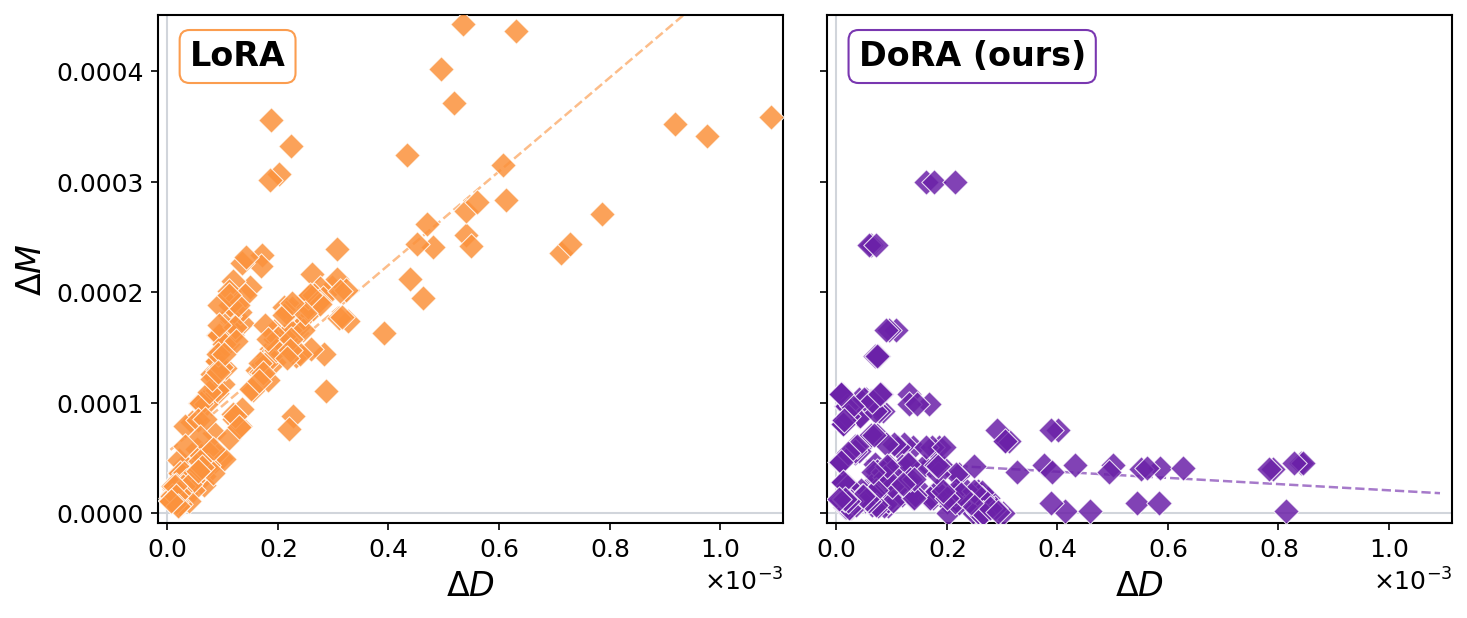

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats as _scistats
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

# --- Configuration ---
main_rank = config.rank
CUSTOM_COLORS = {"lora": "#fb923c", "manual_dora": "#6b21a8"}
CUSTOM_LABELS = {"lora": "LoRA", "manual_dora": "DoRA (ours)"}

MODULE_ORDER = ["q_proj", "k_proj", "v_proj", "up_proj", "down_proj"]

def _module_points_for_variant(variant_name):
    delta_m, delta_d, types = [], [], []
    for k, v in results.items():
        if not (isinstance(v, dict) and v.get("variant") == variant_name
                and v.get("rank") == main_rank and v.get("md_summary")):
            continue
        for _name, d in v["md_summary"].items():
            delta_m.append(abs(d["delta_m_mean"]))
            delta_d.append(d["delta_d_mean"])
            types.append(d["module_type"])
    return np.asarray(delta_m), np.asarray(delta_d), types

trained_variants = [v for v in ("lora", "manual_dora") if len(_module_points_for_variant(v)[0]) > 0]
panel_data = {var: _module_points_for_variant(var) for var in trained_variants}

# Calculate global limits
all_dm = np.concatenate([panel_data[v][0] for v in trained_variants])
all_dd = np.concatenate([panel_data[v][1] for v in trained_variants])

dm_lo, dm_hi = all_dm.min(), all_dm.max()
dd_lo, dd_hi = all_dd.min(), all_dd.max()

dm_pad = 0.02 * (dm_hi - dm_lo) if (dm_hi - dm_lo) > 1e-9 else 0.01
dd_pad = 0.02 * (dd_hi - dd_lo) if (dd_hi - dd_lo) > 1e-9 else 1e-5

n_panels = len(trained_variants)
fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 4.5), sharey=True, sharex=True)
if n_panels == 1: axes = [axes]

for ax, var in zip(axes, trained_variants):
    dm, dd, _ = panel_data[var]
    color = CUSTOM_COLORS.get(var, "#333333")
    label = CUSTOM_LABELS.get(var, var)

    ax.scatter(dd, dm, color=color, marker="D",
               s=75, alpha=0.85, edgecolors="white", linewidth=0.5, zorder=3)

    if len(dm) >= 2:
        slope, intercept = np.polyfit(dd, dm, 1)
        xs = np.array([dd_lo, dd_hi])
        ax.plot(xs, slope * xs + intercept, color=color, linestyle="--", linewidth=1.2, alpha=0.6)

        ax.text(0.05, 0.95, label, transform=ax.transAxes, fontsize=16, fontweight="bold",
                va="top", bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=color, alpha=0.9))

    ax.axhline(0, color="#D1D5DB", linewidth=1.0, zorder=1)
    ax.axvline(0, color="#D1D5DB", linewidth=1.0, zorder=1)

    ax.set_xlim(dd_lo - dd_pad, dd_hi + dd_pad)
    ax.set_ylim(dm_lo - dm_pad, dm_hi + dm_pad)

    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)

    ax.xaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

    ax.set_xlabel(r"$\Delta D$", fontsize=16)
    if ax is axes[0]:
        ax.set_ylabel(r"$\Delta M$", fontsize=16)

plt.tight_layout()
plt.subplots_adjust(bottom=0.2)

md_scatter_path = os.path.join(config.output_dir, "md_scatter_tight.png")
plt.savefig(md_scatter_path, dpi=300, bbox_inches="tight")
plt.show()

Saved refined comparison to /content/gdrive/MyDrive/DoRAFinalProject/Results/md_rank_comparison.png


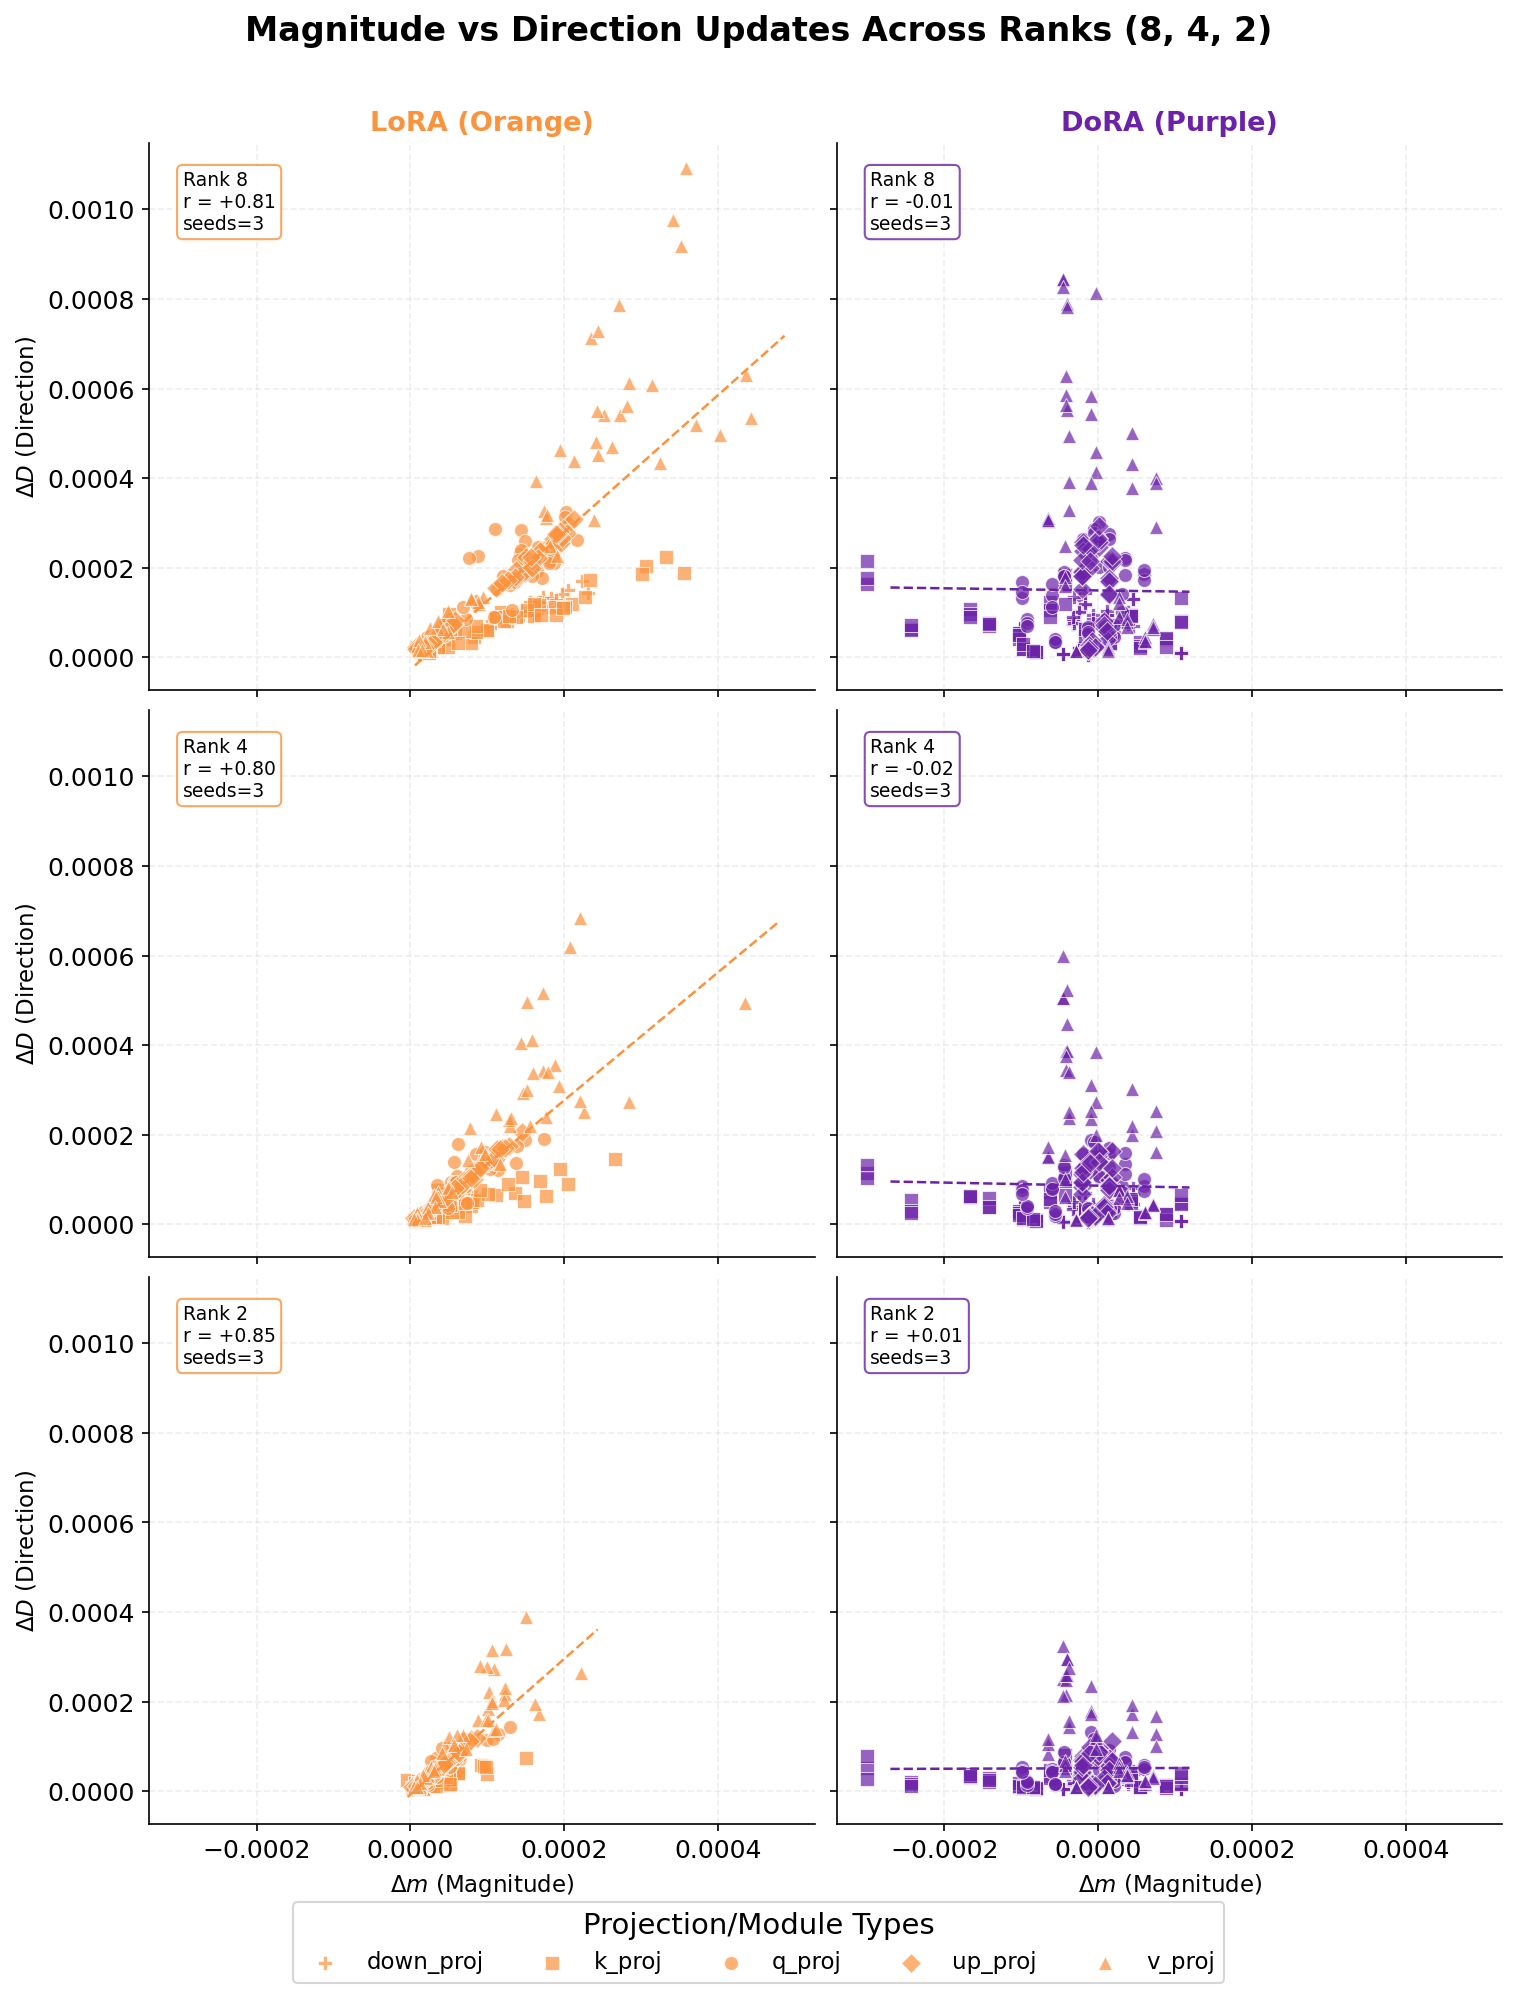

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats as _scistats

# Configuration
ranks_to_plot = [8, 4, 2]
variants = ["lora", "manual_dora"]
# Colors: LoRA = Orange, DoRA = Purple
COLOR_MAP = {"lora": "#fb923c", "manual_dora": "#6b21a8"}
LABEL_MAP = {"lora": "LoRA (Orange)", "manual_dora": "DoRA (Purple)"}

MARKER_BY_TYPE = {
    "q_proj": "o", "k_proj": "s", "v_proj": "^",
    "up_proj": "D", "down_proj": "P",
    "o_proj": "X", "gate_proj": "v",
}

def get_md_points(variant_name, rank):
    """Aggregate (Δm, ΔD, module_type) points for a specific rank."""
    delta_m, delta_d, types = [], [], []
    seeds = set()
    for k, v in results.items():
        if not (isinstance(v, dict) and v.get("variant") == variant_name
                and v.get("rank") == rank and v.get("md_summary")):
            continue
        seeds.add(v.get("seed"))
        for _name, d in v["md_summary"].items():
            delta_m.append(d["delta_m_mean"])
            delta_d.append(d["delta_d_mean"])
            types.append(d["module_type"])
    return np.asarray(delta_m), np.asarray(delta_d), types, len(seeds)

# Create 3x2 Grid (Rows=Ranks, Cols=Variants)
fig, axes = plt.subplots(len(ranks_to_plot), len(variants),
                         figsize=(10, 12),
                         sharex=True, sharey=True,
                         constrained_layout=True)

for i, rank in enumerate(ranks_to_plot):
    for j, var in enumerate(variants):
        ax = axes[i, j]
        dm, dd, types, n_seeds = get_md_points(var, rank)

        if len(dm) == 0:
            ax.text(0.5, 0.5, "No Data", ha='center')
            continue

        color = COLOR_MAP[var]

        # Plot each module type
        for t in sorted(set(types)):
            mask = np.asarray([tt == t for tt in types])
            ax.scatter(dm[mask], dd[mask],
                       color=color, marker=MARKER_BY_TYPE.get(t, "o"),
                       s=45, alpha=0.7, edgecolors="white", linewidth=0.5, label=t)

        # Regression and Statistics
        if len(dm) >= 3:
            r, p = _scistats.pearsonr(dm, dd)
            slope, intercept = np.polyfit(dm, dd, 1)
            xs = np.linspace(dm.min()*0.9, dm.max()*1.1, 50)
            ax.plot(xs, slope * xs + intercept, color=color, linestyle="--", linewidth=1.2)

            # Text box with correlation info
            stats_text = f"Rank {rank}\nr = {r:+.2f}\nseeds={n_seeds}"
            ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
                    va="top", fontsize=9, bbox=dict(boxstyle="round", fc="white", ec=color, alpha=0.8))

        # Aesthetics
        if i == len(ranks_to_plot) - 1:
            ax.set_xlabel(r"$\Delta m$ (Magnitude)", fontsize=11)
        if j == 0:
            ax.set_ylabel(r"$\Delta D$ (Direction)", fontsize=11)

        if i == 0:
            ax.set_title(LABEL_MAP[var], fontsize=13, fontweight='bold', color=color)

        ax.grid(alpha=0.2, linestyle="--")

# Unified Legend for Projection Types
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(MARKER_BY_TYPE),
           bbox_to_anchor=(0.5, -0.05), title="Projection/Module Types")

fig.suptitle(r"Magnitude vs Direction Updates Across Ranks (8, 4, 2)",
             fontsize=16, fontweight="bold", y=1.05)

md_comparison_path = os.path.join(config.output_dir, "md_rank_comparison.png")
plt.savefig(md_comparison_path, dpi=200, bbox_inches="tight")
print(f"Saved refined comparison to {md_comparison_path}")

## 8. Rank Scaling: LoRA vs DoRA (paper's distinctive low-rank claim)

The DoRA paper's most distinctive empirical finding is that **DoRA's
advantage over LoRA grows as rank decreases** — at high rank LoRA can
already absorb most of the directional information, but at low rank the
explicit magnitude parameter buys DoRA real headroom. This cell plots
average accuracy across the 8 commonsense tasks as a function of rank
for both methods, with error bars from seeds where multiple are available.


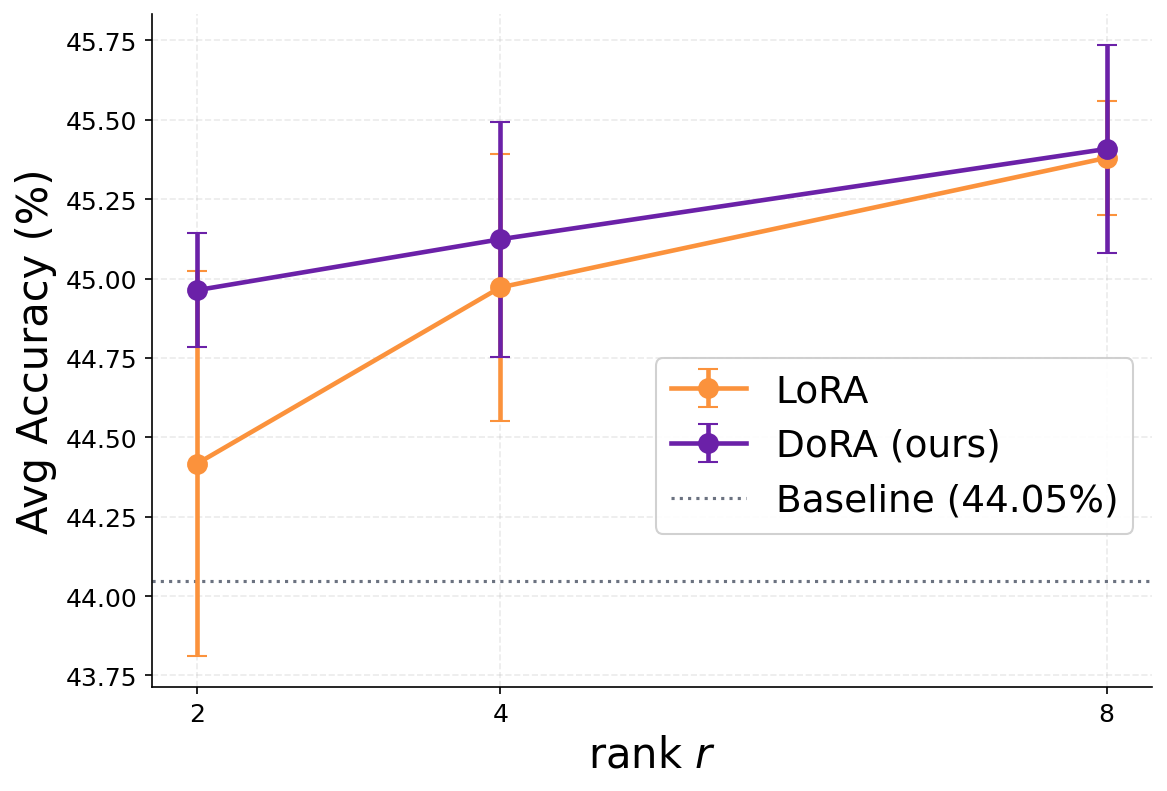


=== DoRA − LoRA gap at each rank (Avg accuracy %) ===
  rank          LoRA     DoRA (manual)      gap (pp)
----------------------------------------------------
     2         44.42             44.96         +0.55
     4         44.97             45.12         +0.15
     8         45.38             45.41         +0.03


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Updated color palette for clarity
dora_color_palette = ["#fb923c", "#6b21a8", "#2dd4bf"]

def _avg_acc_per_run(run_dict):
    """Mean accuracy across the 8 commonsense tasks (in %)."""
    accs = [run_dict["benchmarks"].get(bn, np.nan) for bn in bench_names]
    accs = [a * 100 for a in accs if not np.isnan(a)]
    return float(np.mean(accs)) if accs else float("nan")

# Discover data
present = {}
for k, v in results.items():
    if not (isinstance(v, dict) and "variant" in v):
        continue
    var, rank = v["variant"], v["rank"]
    present.setdefault((var, rank), []).append(_avg_acc_per_run(v))

methods_for_scaling = ["lora", "manual_dora"]
ranks = sorted({r for (var, r) in present.keys() if var in methods_for_scaling})

if not ranks:
    print("No rank-sweep data available.")
else:
    fig, ax = plt.subplots(figsize=(8, 5.5))

    # Plot LoRA and DoRA
    for i, var in enumerate(methods_for_scaling):
        xs, ys, errs = [], [], []
        for r in ranks:
            scores = present.get((var, r), [])
            if not scores: continue
            xs.append(r)
            ys.append(np.mean(scores))
            errs.append(np.std(scores, ddof=1) if len(scores) > 1 else 0.0)

        if not xs: continue
        color = dora_color_palette[i]
        label = "LoRA" if var == "lora" else "DoRA (ours)"
        ax.errorbar(xs, ys, yerr=errs, marker="o", markersize=9,
                    color=color, linewidth=2.2, capsize=5,
                    label=label, zorder=3)

    # Plot Baseline
    base_avg = _avg_acc_per_run(results.get("base", {}))
    if not np.isnan(base_avg):
        ax.axhline(base_avg, color="#6B7280", linestyle=":", linewidth=1.5,
                   label=f"Baseline ({base_avg:.2f}%)")

    # Legend Ordering Logic
    handles, labels = ax.get_legend_handles_labels()
    # Explicitly map labels to desired order
    desired_order = ["LoRA", "DoRA (ours)", f"Baseline ({base_avg:.2f}%)"]
    handle_map = dict(zip(labels, handles))
    ordered_handles = [handle_map[l] for l in desired_order if l in handle_map]
    ordered_labels = [l for l in desired_order if l in handle_map]

    ax.legend(ordered_handles, ordered_labels, loc="lower right",
              fontsize=18, framealpha=0.9, bbox_to_anchor=(1.0, 0.2))

    ax.set_xlabel("rank $r$", fontsize=20)
    ax.set_ylabel("Avg Accuracy (%)", fontsize=20)
    ax.set_xticks(ranks)
    ax.grid(alpha=0.25, linestyle="--")

    plt.tight_layout()
    plt.savefig(os.path.join(config.output_dir, "rank_scaling.png"), dpi=300)
    plt.show()


    # ── Print the gap (DoRA − LoRA) at each rank ──────────────────────────
    print("\n=== DoRA − LoRA gap at each rank (Avg accuracy %) ===")
    print(f"{'rank':>6}{'LoRA':>14}{'DoRA (manual)':>18}{'gap (pp)':>14}")
    print("-" * 52)
    for r in ranks:
        lora_scores = present.get(("lora", r), [])
        dora_scores = present.get(("manual_dora", r), [])
        if not lora_scores or not dora_scores:
            continue
        lora_mean = np.mean(lora_scores)
        dora_mean = np.mean(dora_scores)
        gap = dora_mean - lora_mean
        print(f"{r:>6d}{lora_mean:>14.2f}{dora_mean:>18.2f}{gap:>+14.2f}")
    # Caption
    # Figure. Average accuracy of LoRA and DoRA and baseline for varying ranks
    # for LLaMA-3.2-1B on the commonsense reasoning tasks.
    # Figure. LLaMA-3.2-1B performance (average accuracy) on commonsense reasoning tasks, comparing LoRA and DoRA vs. baseline across varying ranks.
